In [1]:
# the first can only be run by the other conda environment (to keep versions consistent with science cloud), so here we read the transformed data for plotting etc.


import pandas as pd

from data_analysis.dataloader.dataloader import PittDataLoader

from datetime import datetime
now = lambda: datetime.now().strftime("%Y-%m-%d %H:%M")


TARGET = 'language'
#TARGET = 'memory'
#TARGET = "executive_function"
#TARGET = "speed"

FEATURES = "linguistics_only"
FEATURES = "linguistics_and_demographics"
#FEATURES = "demographics_only"

if FEATURES == 'linguistics_only':
    # linguistics_only
    results = pd.read_csv(f"./pitt_predictions_linguistics_{TARGET}.csv", sep=";")

elif FEATURES == 'linguistics_and_demographics':
    # linguistic and demographics
    results = pd.read_csv(f"./pitt_predictions_linguistics_and_demographics_{TARGET}.csv", sep=";")

elif FEATURES == 'demographics_only':
    results = pd.read_csv(f"./pitt_predictions_demographics_only_{TARGET}.csv", sep=";")

results['sample_name_longitudinal'] = results['sample_name'].apply(lambda x: x.split("-")[0])
results

/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/webrtcvad.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,sample_name,prediction,mmse,sample_name_longitudinal
0,001-0,-0.863706,18.0,001
1,001-2,-0.752849,11.0,001
2,002-0,0.297256,30.0,002
3,002-1,-0.185485,30.0,002
4,002-2,0.484023,30.0,002
...,...,...,...,...
544,707-0,-0.394518,21.0,707
545,709-0,-1.208057,26.0,709
546,709-2,-0.561049,NaN,709
547,711-0,-0.837165,25.0,711


In [25]:
pitt_data = PittDataLoader().load_data()

No task specified, loading cookie
No consent_filter specified (consent for further data use), loading all participants
Initializing Audio Cutter
Initializing dataloader PITT Dataloader (transcript_version manual, task cookie, only_PAR True)
Loading data using dataloader PITT Dataloader
Loading 243 PITT Control / cookie recordings...
Loading 306 PITT Dementia / cookie recordings...
Cross-checking the CHAT headers against the metadata spreadsheet:
   MMSE: 457 visits comparable, 2 disagreeing -> 493-1 (15 vs 9), 515-1 (12 vs 18)
   diagnosis: 378 visits comparable, 1 disagreeing -> 172-1 (CHAT MCI vs code 800 = Control)
   sex: 549 visits comparable, 0 disagreeing
   age at first visit: 241 visits comparable, 0 disagreeing

ATTENTION: the visit dates of 3 participants contradict the age in the CHAT header, so one of the two sources is wrong for them:
   participant 158, visit 1 -> 2: +0.00 years by date vs +1 by age
   participant 158, visit 2 -> 3: +2.06 years by date vs +1 by age
   pa

/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [26]:
pitt_data.demographics

,age,gender_unified,education_years,education_binary,country,diagnosis,group
0,57.0,m,14,low-education,usa,ProbableAD,Dementia
1,59.0,m,14,low-education,usa,ProbableAD,Dementia
2,58.0,f,16,high-education,usa,Control,Control
3,59.0,f,16,high-education,usa,Control,Control
4,60.0,f,16,high-education,usa,Control,Control
...,...,...,...,...,...,...,...
544,74.0,f,11,low-education,usa,PossibleAD,Dementia
545,74.0,f,12,low-education,usa,Control,Control
546,76.0,f,12,low-education,usa,Control,Control
547,77.0,m,16,high-education,usa,PossibleAD,Dementia


In [27]:
pitt_metadata = pitt_data.demographics
pitt_metadata['sample_name_longitudinal'] = pitt_data.sample_names_longitudinal
pitt_metadata['sample_name'] = pitt_data.sample_names
pitt_metadata = pitt_metadata.sort_values(by='sample_name').groupby('sample_name_longitudinal').agg(
    age=('age', 'mean'),
    gender=('gender_unified', 'first'),
    education_years=('education_years', 'mean'),
    education_binary=('education_binary', 'first'),
    country=('country', 'first'),
    #diagnosis=('diagnosis', lambda x: x.iloc[0] if len(set(x)) == 1 else str(list(x))),
    #group=('group', lambda x: x.iloc[0] if len(set(x)) == 1 else str(list(x))),
    diagnosis=('diagnosis', 'last'),
    group=('group', 'last')
).reset_index()
pitt_metadata


,sample_name_longitudinal,age,gender,education_years,education_binary,country,diagnosis,group
0,001,58.0,m,14.0,low-education,usa,ProbableAD,Dementia
1,002,59.5,f,16.0,high-education,usa,Control,Control
2,003,56.0,m,17.0,high-education,usa,ProbableAD,Dementia
3,005,54.0,m,9.0,low-education,usa,ProbableAD,Dementia
4,006,73.0,m,16.0,high-education,usa,Control,Control
...,...,...,...,...,...,...,...,...
286,705,71.0,f,12.0,low-education,usa,ProbableAD,Dementia
287,707,74.0,f,11.0,low-education,usa,PossibleAD,Dementia
288,709,75.0,f,12.0,low-education,usa,Control,Control
289,711,77.0,m,16.0,high-education,usa,PossibleAD,Dementia


Text(0, 0.5, 'Prediction')

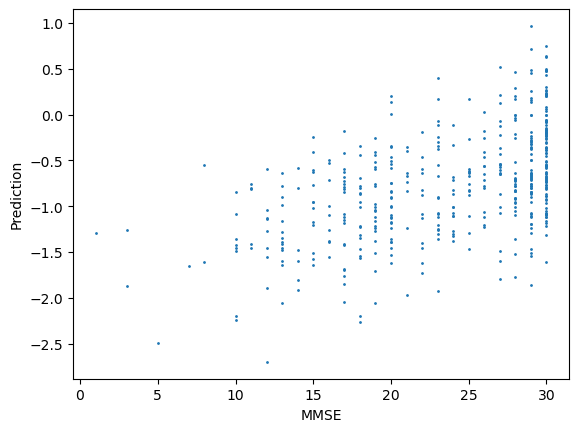

In [28]:
import matplotlib.pyplot as plt

plt.scatter(results['mmse'], results['prediction'], s=1)
plt.xlabel("MMSE")
plt.ylabel("Prediction")

In [29]:
import numpy as np, pandas as pd, statsmodels.api as sm, warnings
from scipy import stats
PARTICIPANT = 'sample_name_longitudinal'

def fit_within_between_model(data):
    """Mixed model splitting MMSE into within- and between-person components."""
    data = data.copy()
    data['mmse'] = data['mmse'].astype(float)
    data['prediction'] = data['prediction'].astype(float)
    data['mmse_person_first'] = data.groupby(PARTICIPANT)['mmse'].transform('first')
    data['mmse_deviation_from_person_first'] = data['mmse'] - data['mmse_person_first']
    return sm.MixedLM.from_formula("prediction ~ mmse_deviation_from_person_first + mmse_person_first", groups=PARTICIPANT, data=data).fit()#(method='lbfgs')


def fit_within_between_model_mundlak(data):
    """Mundlak parameterization of the above."""
    data = data.copy()
    data['mmse'] = data['mmse'].astype(float)
    data['prediction'] = data['prediction'].astype(float)
    data['mmse_person_first'] = data.groupby(PARTICIPANT)['mmse'].transform('first')
    return sm.MixedLM.from_formula("prediction ~ mmse + mmse_person_first", groups=PARTICIPANT, data=data).fit()#(method='lbfgs')


def print_effect(model, coefficient, label):
    lower, upper = model.conf_int().loc[coefficient]
    print(f"{label} --> {model.params[coefficient]: .4f}  [{lower: .4f}, {upper: .4f}]")

WITHIN, BETWEEN = 'mmse_deviation_from_person_first', 'mmse_person_first'

# usable = >=2 visits after dropna, with MMSE variation
complete_cases = results.dropna()
visit_counts = complete_cases[PARTICIPANT].value_counts()
longitudinal = complete_cases[complete_cases[PARTICIPANT].isin(visit_counts[visit_counts > 1].index)]
has_mmse_variation = longitudinal.groupby(PARTICIPANT)['mmse'].agg(lambda s: s.nunique() > 1)
longitudinal = longitudinal[longitudinal[PARTICIPANT].isin(has_mmse_variation[has_mmse_variation].index)]

max_mmse_per_participant = longitudinal.groupby(PARTICIPANT)['mmse'].max()
below_ceiling = longitudinal[longitudinal[PARTICIPANT].isin(max_mmse_per_participant[max_mmse_per_participant <= 29].index)]

model_all = fit_within_between_model(longitudinal)
print("MODEL ALL DATA:")
print(model_all.summary())
model_below_ceiling = fit_within_between_model(below_ceiling)
print("MODEL BELOW MMSE CEILING:")
print(model_below_ceiling.summary())

print("MODEL BELOW MMSE CEILING MUNDLAK")
model_below_ceiling_mundlak = fit_within_between_model_mundlak(below_ceiling)
print(model_below_ceiling_mundlak.summary())


MODEL ALL DATA:
                   Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       prediction
No. Observations:        230           Method:                   REML      
No. Groups:              94            Scale:                    0.1727    
Min. group size:         2             Log-Likelihood:           -171.0042 
Max. group size:         5             Converged:                Yes       
Mean group size:         2.4                                               
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                        -1.774    0.234 -7.584 0.000 -2.232 -1.315
mmse_deviation_from_person_first  0.031    0.010  2.979 0.003  0.011  0.051
mmse_person_first                 0.043    0.009  4.719 0.000  0.025  0.061
sample_name_lon

In [30]:
import os
def write_model_output(model, version):
    coefs = pd.DataFrame({'coef': model.params})
    ci = model.conf_int()
    ci.columns=['ci_low', 'ci_high']
    pval = pd.DataFrame({'pval': model.pvalues})
    out = pd.concat((coefs, pval, ci), axis=1)
    out['target'] = TARGET
    out['version'] = version
    out['n_obs'] = model.nobs
    out['n_persons'] = len(model.random_effects)
    out['feature_set'] = FEATURES

    out_file = "between_vs_within_effect.csv"
    if os.path.exists(out_file):
        file_content = pd.read_csv(out_file, index_col=0)
        file_content = file_content[~((file_content['target'] == TARGET) & (file_content['version'] == version) & (file_content['feature_set'] == FEATURES))]
        file_content = pd.concat((file_content, out), axis=0)
    else:
        file_content = out
    file_content.to_csv(out_file, index=True)
    return out

write_model_output(model_below_ceiling_mundlak, "mundlak")
write_model_output(model_below_ceiling, "between-vs-within")


,coef,pval,ci_low,ci_high,target,version,n_obs,n_persons,feature_set
Intercept,-1.473148,1.907264e-08,-1.986886,-0.959409,language,between-vs-within,151,65,linguistics_and_demographics
mmse_deviation_from_person_first,0.030675,4.670577e-03,0.009423,0.051928,language,between-vs-within,151,65,linguistics_and_demographics
mmse_person_first,0.028579,1.053578e-02,0.006679,0.050478,language,between-vs-within,151,65,linguistics_and_demographics
sample_name_longitudinal Var,0.358398,5.467828e-02,-0.007189,0.723985,language,between-vs-within,151,65,linguistics_and_demographics


In [31]:
fit_measures = {
    'version': 'below_mmse_ceiling',

}

In [32]:

n_all, n_below = longitudinal[PARTICIPANT].nunique(), below_ceiling[PARTICIPANT].nunique()
print_effect(model_all, BETWEEN, f"between-person (n={n_all})")
print_effect(model_all, WITHIN,  f"within-person  (n={n_all})")
print_effect(model_below_ceiling, BETWEEN, f"between, below ceiling (n={n_below})")
print_effect(model_below_ceiling, WITHIN, f"within, below ceiling (n={n_below})")

# difference: covariance term is required, the two estimates are not independent
coefficient_covariance = model_all.cov_params().loc[[WITHIN, BETWEEN], [WITHIN, BETWEEN]]
within_minus_between = model_below_ceiling.params[WITHIN] - model_below_ceiling.params[BETWEEN]
difference_se = np.sqrt(coefficient_covariance.iloc[0, 0] + coefficient_covariance.iloc[1, 1] - 2 * coefficient_covariance.iloc[0, 1])
print(f"\nwithin - between: {within_minus_between: .4f}  "
      f"[{within_minus_between - 1.96*difference_se: .4f}, "
      f"{within_minus_between + 1.96*difference_se: .4f}]"
      f"   p = {2*stats.norm.sf(abs(within_minus_between/difference_se)):.3f}")

equivalence_margin = model_below_ceiling.params[BETWEEN] / 2   # placeholder, not a scientific judgment
tost_p = max(stats.norm.sf((within_minus_between + equivalence_margin) / difference_se),
             stats.norm.cdf((within_minus_between - equivalence_margin) / difference_se))
print(f"TOST vs +-{equivalence_margin:.4f} --> p = {tost_p:.3f}"
      f"  ({'equivalent' if tost_p < .05 else 'NOT equivalent'})")

between-person (n=94) -->  0.0431  [ 0.0252,  0.0610]
within-person  (n=94) -->  0.0309  [ 0.0106,  0.0512]
between, below ceiling (n=65) -->  0.0286  [ 0.0067,  0.0505]
within, below ceiling (n=65) -->  0.0307  [ 0.0094,  0.0519]

within - between:  0.0021  [-0.0269,  0.0311]   p = 0.887
TOST vs +-0.0143 --> p = 0.205  (NOT equivalent)


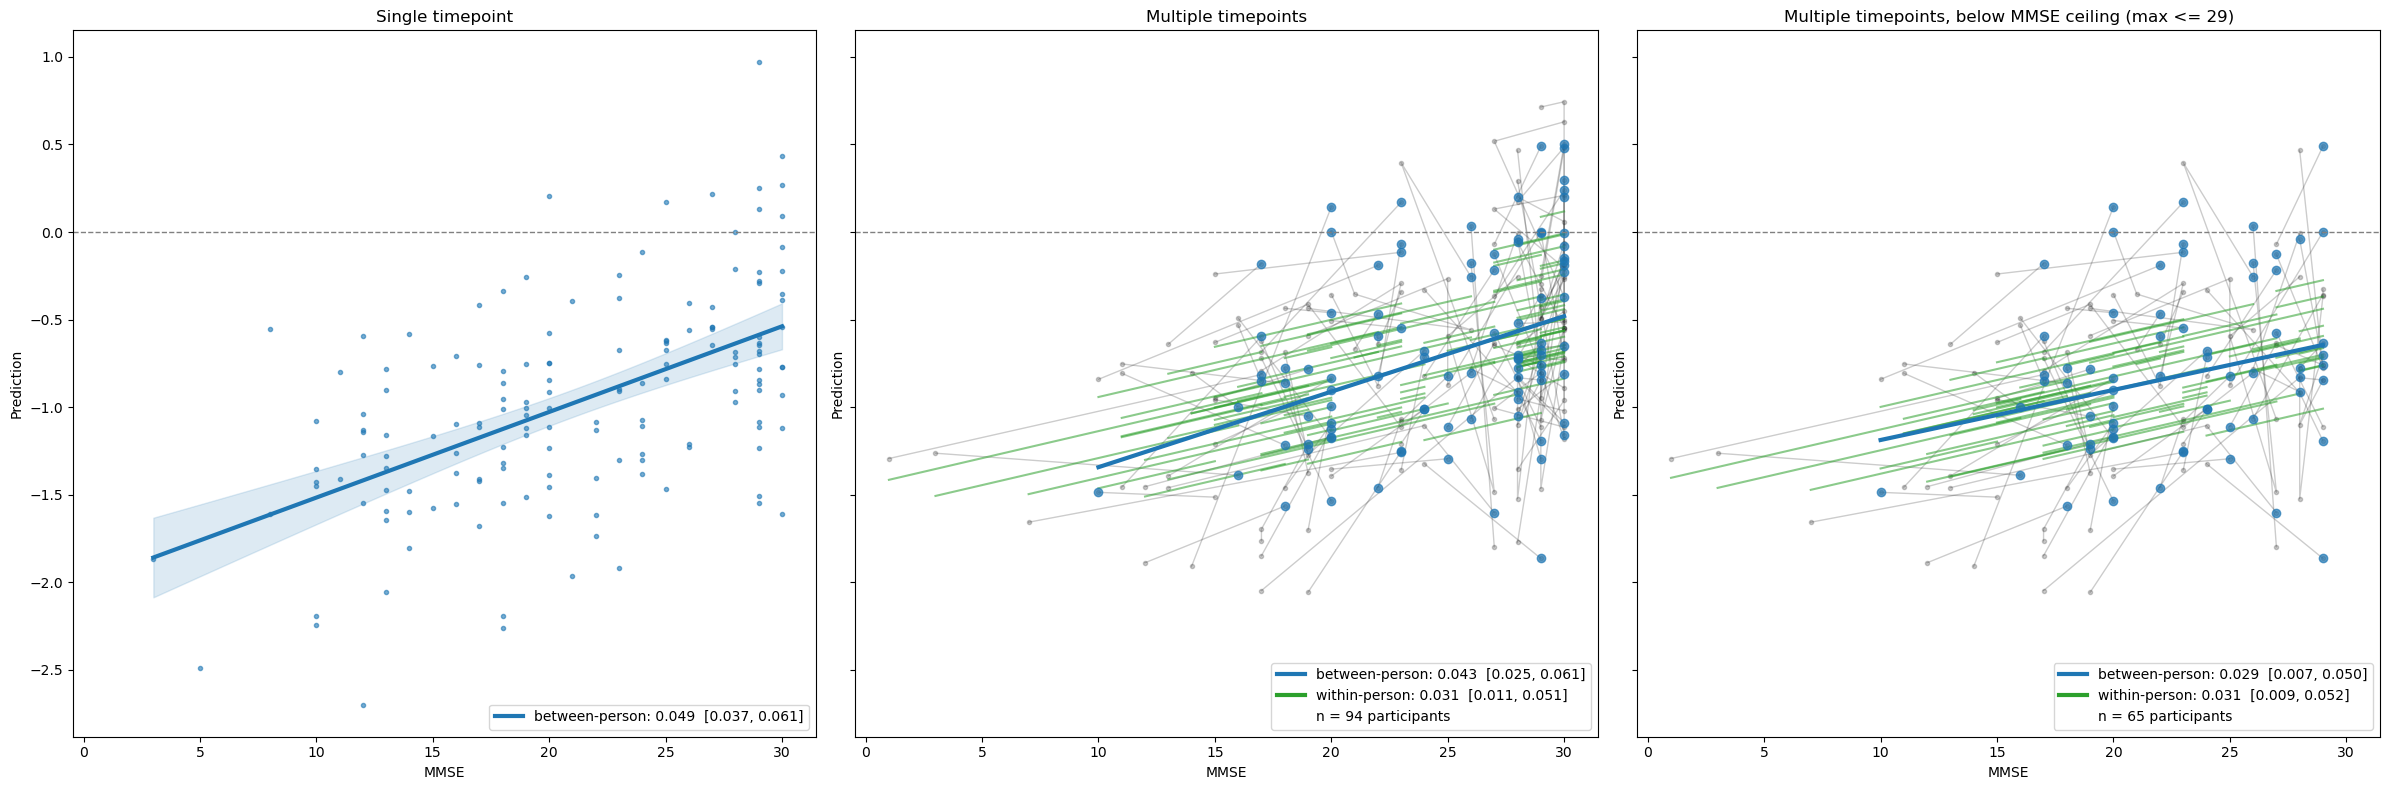

In [33]:
import warnings
import numpy as np, pandas as pd, statsmodels.api as sm
import matplotlib.pyplot as plt

PARTICIPANT = 'sample_name_longitudinal'

def fit_within_between(data):
    """Random-intercept mixed model with MMSE split into person mean and deviation."""
    data = data.copy()
    data['mmse'] = data['mmse'].astype(float)
    data['prediction'] = data['prediction'].astype(float)
    data['mmse_person_first'] = data.groupby(PARTICIPANT)['mmse'].transform('first')
    data['mmse_deviation'] = data['mmse'] - data['mmse_person_first']
    data = data[data.groupby(PARTICIPANT)['mmse'].transform('nunique') > 1]   # needs MMSE variation
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = sm.MixedLM.from_formula("prediction ~ mmse_deviation + mmse_person_first",
                                        groups=PARTICIPANT, re_formula="1", data=data).fit(method='lbfgs')
    return model, data


def plot_between_only(ax, data):
    """Single visit per person: only a between-person slope is identifiable."""
    ax.plot(data['mmse'], data['prediction'], '.', color='tab:blue', alpha=0.6)
    model = sm.OLS(data['prediction'].astype(float),
                   sm.add_constant(data['mmse'].astype(float))).fit()
    lo, hi = model.conf_int().loc['mmse']
    grid = np.linspace(data['mmse'].min(), data['mmse'].max(), 100)
    band = model.get_prediction(sm.add_constant(grid)).summary_frame()
    ax.plot(grid, band['mean'], '-', color='tab:blue', lw=3,
            label=f"between-person: {model.params['mmse']:.3f}  [{lo:.3f}, {hi:.3f}]")
    ax.fill_between(grid, band['mean_ci_lower'], band['mean_ci_upper'], color='tab:blue', alpha=0.15)


def plot_within_and_between(ax, data):
    model, data = fit_within_between(data)
    intercept = model.params['Intercept']
    slope_within, slope_between = model.params['mmse_deviation'], model.params['mmse_person_first']
    ci = model.conf_int()
    offsets = model.random_effects

    for pid, g in data.groupby(PARTICIPANT):                      # observed trajectories
        ax.plot(g['mmse'], g['prediction'], marker='.', color='black', alpha=0.2, lw=1)

    for pid, g in data.groupby(PARTICIPANT):                      # fitted within-person lines
        x_first, u = g['mmse'].iloc[0], float(np.ravel(offsets[pid])[0])
        x_ends = np.array([g['mmse'].min(), g['mmse'].max()])
        ax.plot(x_ends, intercept + slope_between * x_first + u + slope_within * (x_ends - x_first),
                color='tab:green', lw=1.5, alpha=0.55)

    person_firsts = data.groupby(PARTICIPANT).agg(x=('mmse', 'first'), y=('prediction', 'first'))
    ax.plot(person_firsts['x'], person_firsts['y'], 'o', color='tab:blue', ms=6, alpha=0.7)
    x_ends = np.array([person_firsts['x'].min(), person_firsts['x'].max()])
    ax.plot(x_ends, intercept + slope_between * x_ends, '-', color='tab:blue', lw=3,
            label=f"between-person: {slope_between:.3f}  "
                  f"[{ci.loc['mmse_person_first'].iloc[0]:.3f}, {ci.loc['mmse_person_first'].iloc[1]:.3f}]")
    ax.plot([], [], color='tab:green', lw=3,
            label=f"within-person: {slope_within:.3f}  "
                  f"[{ci.loc['mmse_deviation'].iloc[0]:.3f}, {ci.loc['mmse_deviation'].iloc[1]:.3f}]")
    ax.plot([], [], ' ', label=f"n = {data[PARTICIPANT].nunique()} participants")


# ---------------------------------------------------------------- data
complete = results.dropna()
visit_counts = complete[PARTICIPANT].value_counts()
single_visit = complete[complete[PARTICIPANT].isin(visit_counts[visit_counts == 1].index)]
longitudinal = complete[complete[PARTICIPANT].isin(visit_counts[visit_counts > 1].index)]

peak_mmse = longitudinal.groupby(PARTICIPANT)['mmse'].max()
below_ceiling = longitudinal[longitudinal[PARTICIPANT].isin(peak_mmse[peak_mmse <= 29].index)]

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
plot_between_only(axes[0], single_visit)
plot_within_and_between(axes[1], longitudinal)
plot_within_and_between(axes[2], below_ceiling)

for ax, title in zip(axes, ["Single timepoint",
                            "Multiple timepoints",
                            "Multiple timepoints, below MMSE ceiling (max <= 29)"]):
    ax.set_title(title); ax.set_xlabel("MMSE"); ax.set_ylabel("Prediction")
    ax.axhline(0, ls='--', color='gray', lw=1)
    ax.legend(loc='lower right', fontsize=10)
plt.tight_layout(); plt.show()

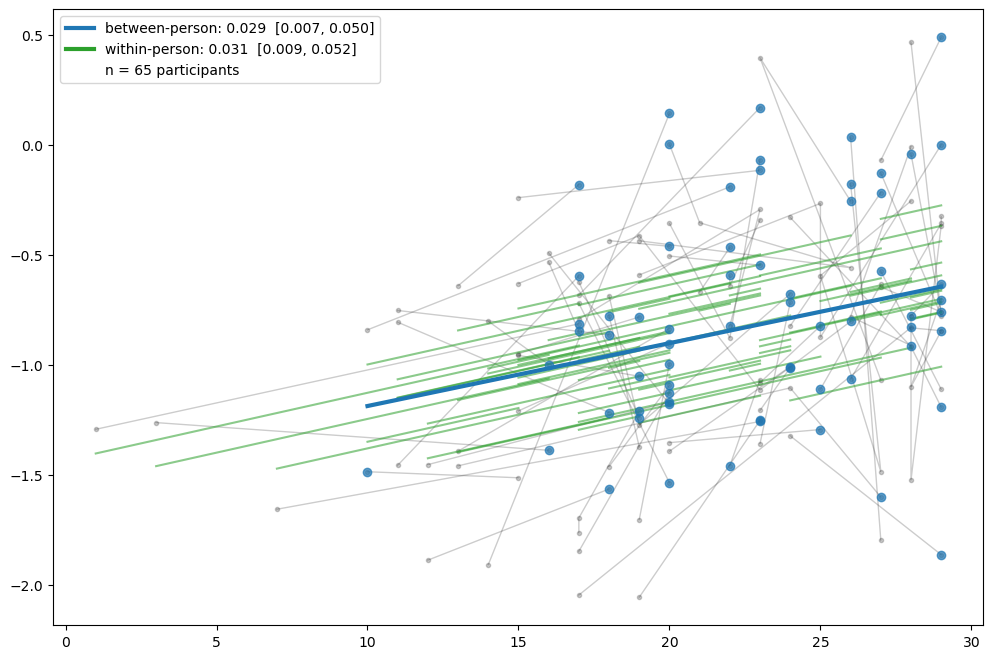

Participants below ceiling: 80
Longitudinal participants total: 128


In [34]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
plot_within_and_between(ax, below_ceiling)
plt.legend()
plt.show()

print("Participants below ceiling:", below_ceiling[PARTICIPANT].nunique())
print("Longitudinal participants total:", longitudinal[PARTICIPANT].nunique())

In [17]:
below_ceiling_with_mmse_variation = below_ceiling[below_ceiling.groupby(PARTICIPANT)['mmse'].transform('nunique') > 1]
below_ceiling_with_mmse_variation_metadata = pitt_metadata[pitt_metadata[PARTICIPANT].isin(below_ceiling_with_mmse_variation[PARTICIPANT])]
below_ceiling_with_mmse_variation_metadata

,sample_name_longitudinal,age,gender,education_years,education_binary,country,diagnosis,group
0,001,58.0,m,14.0,low-education,usa,ProbableAD,Dementia
3,005,54.0,m,9.0,low-education,usa,ProbableAD,Dementia
5,007,74.0,f,14.0,low-education,usa,ProbableAD,Dementia
6,010,68.0,m,12.0,low-education,usa,ProbableAD,Dementia
14,022,79.0,f,12.0,low-education,usa,Control,Control
...,...,...,...,...,...,...,...,...
203,450,74.5,f,6.0,low-education,usa,ProbableAD,Dementia
207,466,78.5,f,14.0,low-education,usa,ProbableAD,Dementia
214,488,64.5,f,12.0,low-education,usa,ProbableAD,Dementia
217,497,70.5,f,14.0,low-education,usa,ProbableAD,Dementia


In [35]:
diagnosis_dict = below_ceiling_with_mmse_variation_metadata.diagnosis.value_counts().to_dict()
diagnosis_string = ", ".join([f"{key}: {val}" for key,val in diagnosis_dict.items()])

In [36]:
def continuous_var_string(var):
    return f"Mean: {var.mean():.1f}, Std: {var.std():.1f}, Min: {var.min():.1f}, Max: {var.max():.1f}"

age_string = continuous_var_string(below_ceiling_with_mmse_variation_metadata.age)
n_visits = continuous_var_string(below_ceiling_with_mmse_variation.groupby(PARTICIPANT).size())
first_mmse = continuous_var_string(below_ceiling_with_mmse_variation.groupby(PARTICIPANT)['mmse'].first())
mmse_range = continuous_var_string(below_ceiling_with_mmse_variation.groupby(PARTICIPANT).apply(lambda g: g.mmse.max() - g.mmse.min()))

In [37]:
demographics_table = pd.Series({
    'Diagnosis': diagnosis_string,
    'Age': age_string,
    'Number of visits per person': n_visits,
    'Within-person first MMSE': first_mmse,
    'Within-person MMSE range (max - min)': mmse_range,
})
demographics_table

Diagnosis                               ProbableAD: 49, Control: 11, MCI: 4, Vascular: 1
Age                                           Mean: 70.3, Std: 8.5, Min: 54.0, Max: 89.0
Number of visits per person                      Mean: 2.3, Std: 0.6, Min: 2.0, Max: 4.0
Within-person first MMSE                      Mean: 22.8, Std: 4.3, Min: 10.0, Max: 29.0
Within-person MMSE range (max - min)            Mean: 4.5, Std: 3.8, Min: 1.0, Max: 16.0
dtype: str

In [38]:

print(demographics_table.to_latex(index=True, header=False, caption=f"Demographic overview of the {below_ceiling_with_mmse_variation_metadata.shape[0]} PITT participants included in our within-person vs.\\ between-person association analysis", label="s_tab:pitt_demographics"))

\begin{table}
\caption{Demographic overview of the 65 PITT participants included in our within-person vs.\ between-person association analysis}
\label{s_tab:pitt_demographics}
\begin{tabular}{ll}
\toprule
\midrule
Diagnosis & ProbableAD: 49, Control: 11, MCI: 4, Vascular: 1 \\
Age & Mean: 70.3, Std: 8.5, Min: 54.0, Max: 89.0 \\
Number of visits per person & Mean: 2.3, Std: 0.6, Min: 2.0, Max: 4.0 \\
Within-person first MMSE & Mean: 22.8, Std: 4.3, Min: 10.0, Max: 29.0 \\
Within-person MMSE range (max - min) & Mean: 4.5, Std: 3.8, Min: 1.0, Max: 16.0 \\
\bottomrule
\end{tabular}
\end{table}

